/home/adithya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Epoch 1/30 | Val Acc: 0.7297
Epoch 2/30 | Val Acc: 0.7946
Epoch 3/30 | Val Acc: 0.8108
Epoch 4/30 | Val Acc: 0.8216
Epoch 5/30 | Val Acc: 0.7892
Epoch 6/30 | Val Acc: 0.8378
Epoch 7/30 | Val Acc: 0.8432
Epoch 8/30 | Val Acc: 0.8378
Epoch 9/30 | Val Acc: 0.7838
Epoch 10/30 | Val Acc: 0.8432
Epoch 11/30 | Val Acc: 0.8162
Epoch 12/30 | Val Acc: 0.8486
Epoch 13/30 | Val Acc: 0.8378
Epoch 14/30 | Val Acc: 0.8324
Epoch 15/30 | Val Acc: 0.8270
Epoch 16/30 | Val Acc: 0.8108
Epoch 17/30 | Val Acc: 0.8378
Epoch 18/30 | Val Acc: 0.8270
Epoch 19/30 | Val Acc: 0.8595
Epoch 20/30 | Val Acc: 0.8162
Epoch 21/30 | Val Acc: 0.8486
Epoch 22/30 | Val Acc: 0.8216
Epoch 23/30 | Val Acc: 0.8378
Epoch 24/30 | Val Acc: 0.8216
Epoch 25/30 | Val Acc: 0.8486
Epoch 26/30 | Val Acc: 0.8324
Epoch 27/30 | Val Acc: 0.8270
Epoch 28/30 | Val Acc: 0.7838
Epoch 29/30 | Val Acc: 0.8378
Epoch 30/30 | Val Acc: 0.8162


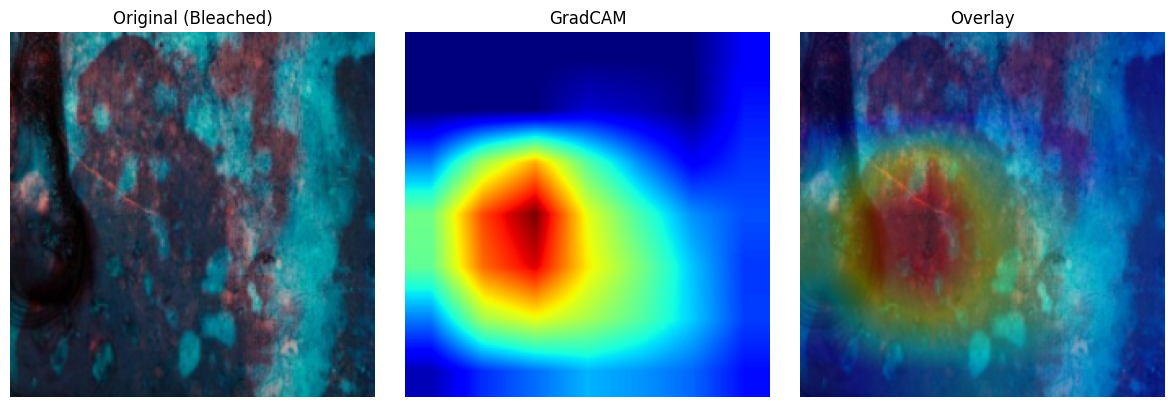

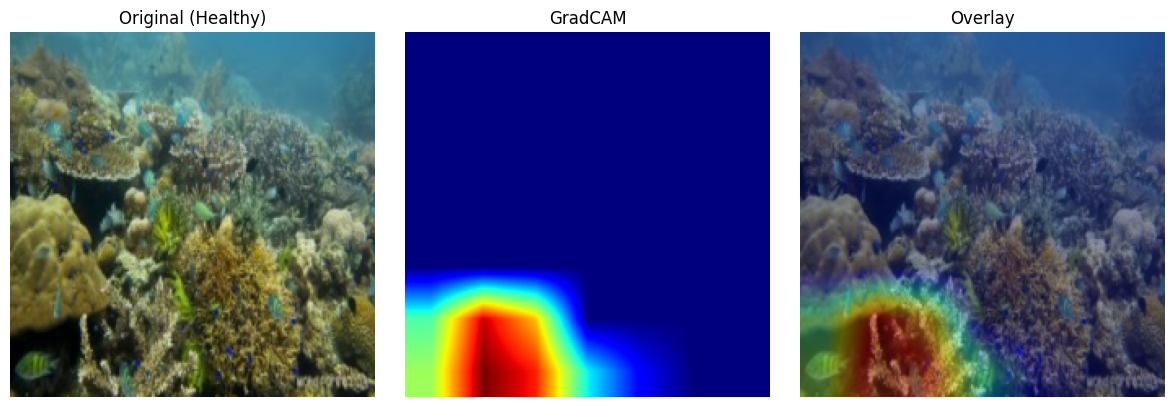

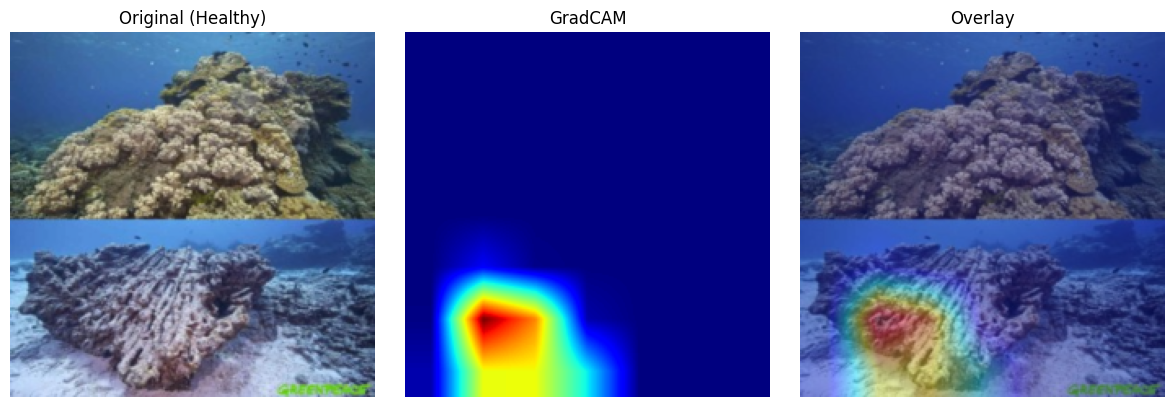

XGBoost (env) Accuracy: 0.7530
Models saved: best_model.pt, xgb_env_model.pkl

CNN
              precision    recall  f1-score   support

     Healthy       0.84      0.88      0.86        88
    Bleached       0.88      0.85      0.86        97

    accuracy                           0.86       185
   macro avg       0.86      0.86      0.86       185
weighted avg       0.86      0.86      0.86       185



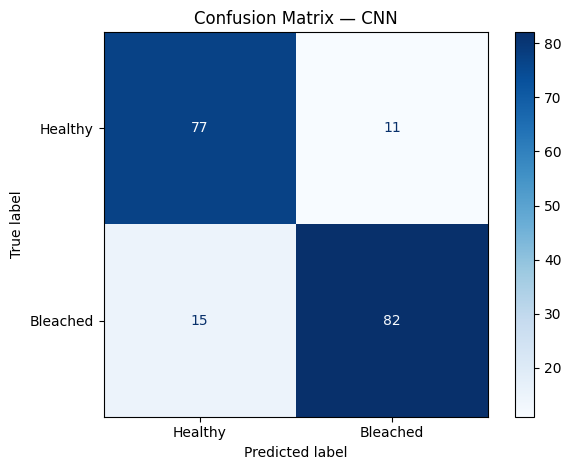


XGBoost_env
              precision    recall  f1-score   support

     Healthy       0.69      0.77      0.73       108
    Bleached       0.81      0.74      0.77       143

    accuracy                           0.75       251
   macro avg       0.75      0.75      0.75       251
weighted avg       0.76      0.75      0.75       251



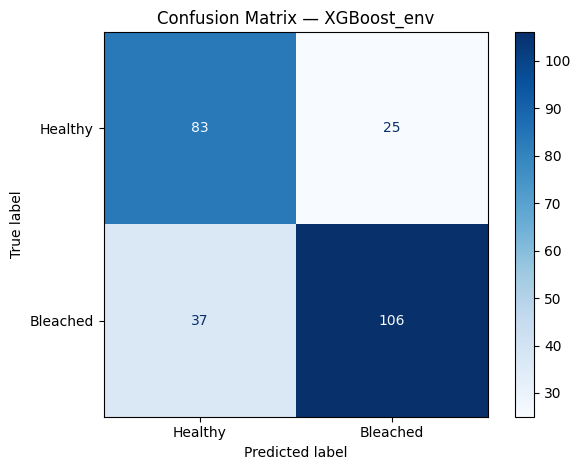

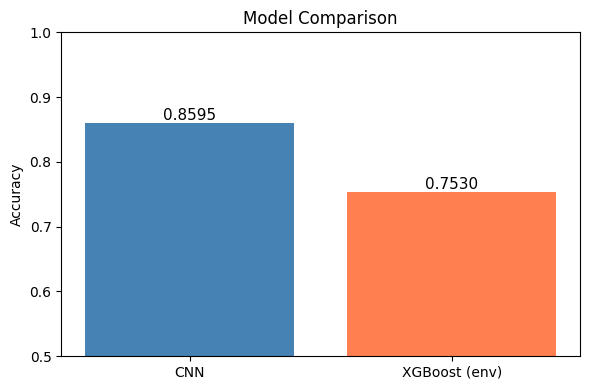

In [1]:
import cv2, os, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, pickle
import torchvision.models as models
import torchvision.transforms as T
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)), T.RandomHorizontalFlip(),
    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)),
    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def load_images(base_dir):
    images, labels = [], []
    for folder, label in [("healthy", 0), ("bleached", 1)]:
        path = os.path.join(base_dir, folder)
        for fname in os.listdir(path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                img = cv2.imread(os.path.join(path, fname))
                images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                labels.append(label)
    return images, labels


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for name, param in model.named_parameters():
        if "layer4" not in name and "fc" not in name:
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(DEVICE)


def train_model(model, train_loader, val_loader, epochs=30):
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
    best_acc  = 0.0

    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss_fn(model(imgs).squeeze(1), labels).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = (torch.sigmoid(model(imgs).squeeze(1)) > 0.5).float()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Val Acc: {acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    model.load_state_dict(torch.load("best_model.pt"))
    return model


def get_cnn_probs(model, val_tensors):
    model.eval()
    with torch.no_grad():
        return np.array([torch.sigmoid(model(t.unsqueeze(0).to(DEVICE))).item() for t in val_tensors])


def get_gradcam(model, img_tensor):
    model.eval()
    saved = {}
    h1 = model.layer4[-1].register_forward_hook(lambda m,i,o: saved.update({"acts": o.detach()}))
    h2 = model.layer4[-1].register_full_backward_hook(lambda m,gi,go: saved.update({"grads": go[0].detach()}))
    model.zero_grad()
    out = model(img_tensor.unsqueeze(0).to(DEVICE))
    out.backward()
    h1.remove(); h2.remove()
    acts  = saved["acts"][0].cpu().numpy()
    grads = saved["grads"][0].cpu().numpy()
    cam   = (grads.mean(axis=(1,2))[:, None, None] * acts).sum(axis=0)
    cam   = np.maximum(cam, 0)
    cam   = (cam - cam.min()) / (cam.max() + 1e-8)
    return cv2.resize(cam, (224, 224))


def show_gradcam(model, img_tensor, label, idx):
    cam  = get_gradcam(model, img_tensor)
    orig = np.clip(
        img_tensor.permute(1,2,0).numpy().astype(np.float64)
        * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1
    )
    heat    = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.65*orig + 0.35*heat, 0, 1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, title in zip(axes, [orig, cam, overlay],
        [f"Original ({'Bleached' if label==1 else 'Healthy'})", "GradCAM", "Overlay"]):
        ax.imshow(img, cmap="jet" if title == "GradCAM" else None)
        ax.set_title(title); ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"gradcam_{idx}.png", dpi=150)
    plt.show()


def evaluate(name, y_true, y_pred):
    print(f"\n{name}\n" + "="*40)
    print(classification_report(y_true, y_pred, target_names=["Healthy", "Bleached"]))
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=["Healthy", "Bleached"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"cm_{name}.png", dpi=150)
    plt.show()


BASE = "../dataset"

images, labels = load_images(BASE)
X_train_imgs, X_val_imgs, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

train_tensors = [train_transform(img) for img in X_train_imgs]
val_tensors   = [val_transform(img)   for img in X_val_imgs]

train_loader = torch.utils.data.DataLoader(
    list(zip(train_tensors, [torch.tensor(l, dtype=torch.float32) for l in y_train])),
    batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    list(zip(val_tensors, [torch.tensor(l, dtype=torch.float32) for l in y_val])),
    batch_size=16)

model = build_model()
model = train_model(model, train_loader, val_loader)

for i in [0, 5, 10]:
    show_gradcam(model, val_tensors[i], y_val[i], i)

cnn_probs = get_cnn_probs(model, val_tensors)
cnn_preds = (cnn_probs > 0.5).astype(int)

ENV_FEATURES = ["Temperature_Mean", "Turbidity", "Windspeed", "Thermal_Stress_Index", "SSTA"]

df = pd.read_csv(os.path.join(BASE, "coral_bleaching_cleaned.csv"))
X_env = df[ENV_FEATURES].values
y_env = (df["Percent_Bleaching"] > 20).astype(int).values

Xt_env, Xv_env, yt_env, yv_env = train_test_split(X_env, y_env, test_size=0.2, random_state=42)
xgb_env = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric="logloss")
xgb_env.fit(Xt_env, yt_env, eval_set=[(Xv_env, yv_env)], verbose=False)

with open("xgb_env_model.pkl", "wb") as f:
    pickle.dump({"model": xgb_env, "features": ENV_FEATURES}, f)

xgb_env_probs = xgb_env.predict_proba(Xv_env)[:, 1]
xgb_env_preds = (xgb_env_probs > 0.5).astype(int)
print(f"XGBoost (env) Accuracy: {(xgb_env_preds==yv_env).mean():.4f}")
print("Models saved: best_model.pt, xgb_env_model.pkl")

y_val_arr = np.array(y_val)
evaluate("CNN", y_val_arr, cnn_preds)
evaluate("XGBoost_env", yv_env, xgb_env_preds)

names = ["CNN", "XGBoost (env)"]
accs  = [(cnn_preds==y_val_arr).mean(), (xgb_env_preds==yv_env).mean()]
plt.figure(figsize=(6, 4))
bars = plt.bar(names, accs, color=["steelblue", "coral"])
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{acc:.4f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()